In [1]:
import pandas as pd

df = pd.read_csv("amz_uk_price_prediction_dataset 2.csv")

df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [3]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [4]:
crosstab = pd.crosstab(df['category'], df['isBestSeller'])
crosstab.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [5]:
crosstab_prop = crosstab.div(crosstab.sum(axis=1), axis=0)

# Sort by best-seller rate
crosstab_prop_sorted = crosstab_prop.sort_values(by=True, ascending=False)

crosstab_prop_sorted.head(10)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
"Billiard, Snooker & Pool",0.967871,0.032129
Pet Supplies,0.969800,0.030200
Home Brewing & Wine Making,0.971545,0.028455
Wind Instruments,0.972000,0.028000


In [6]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 36540.20270061387
p-value: 0.0


In [7]:
import numpy as np

n = crosstab.sum().sum()
phi2 = chi2 / n
r, k = crosstab.shape

cramers_v = np.sqrt(phi2 / min(k-1, r-1))
print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


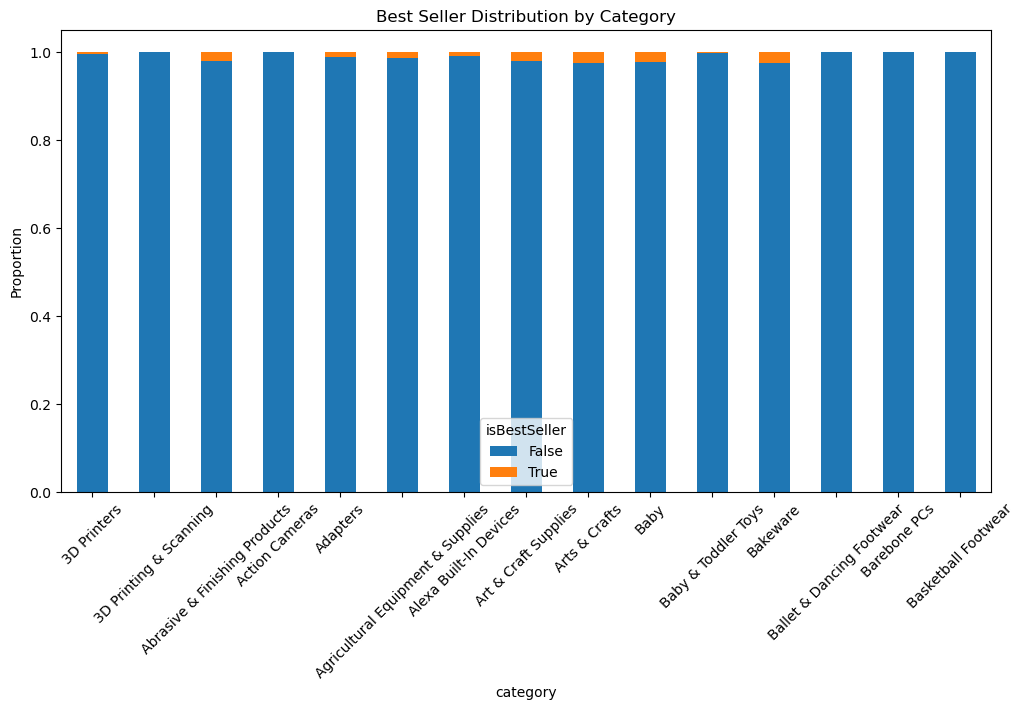

In [8]:
import matplotlib.pyplot as plt

crosstab_prop.head(15).plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Best Seller Distribution by Category")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pd.DataFrame(expected_freq, columns=df['SaleCondition'].unique(), index=crosstab_result.index)


The null hypothesis of the Chi-square test is that the two categorical variables are independent. Given the extremely low \( p \)-value, we reject the null hypothesis. This implies that there's a significant association between `MSZoning` and `SaleCondition` in the dataset.


In [9]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    (df['price'] >= Q1 - 1.5 * IQR) &
    (df['price'] <= Q3 + 1.5 * IQR)
]

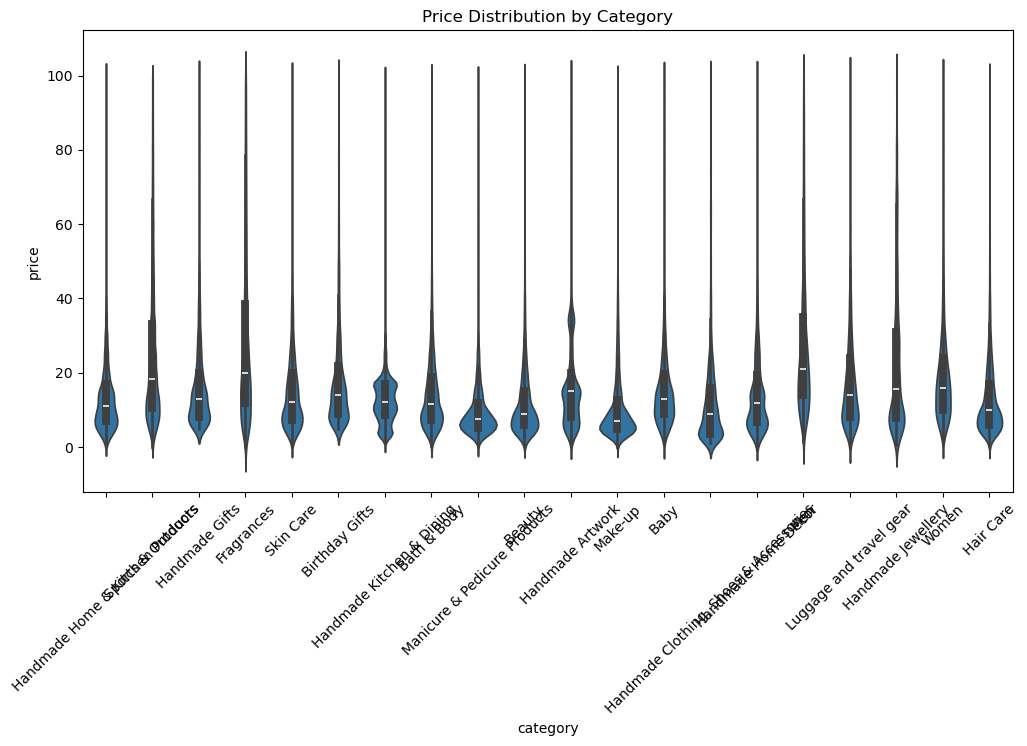

In [10]:
import seaborn as sns

top20 = df_clean['category'].value_counts().head(20).index

plt.figure(figsize=(12,6))
sns.violinplot(data=df_clean[df_clean['category'].isin(top20)],
               x='category', y='price')

plt.xticks(rotation=45)
plt.title("Price Distribution by Category")
plt.show()

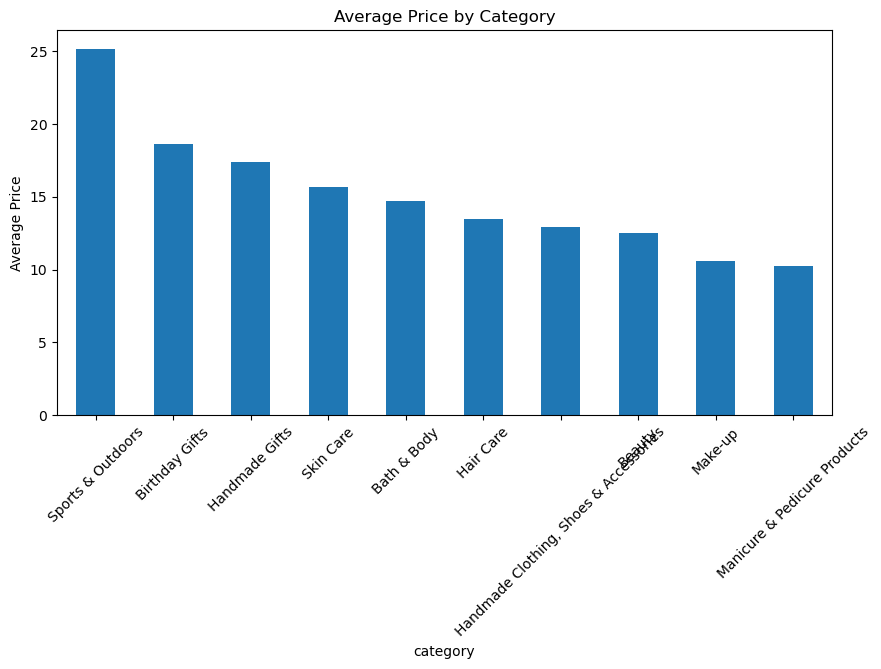

In [11]:
top10 = df_clean['category'].value_counts().head(10).index

avg_price = (
    df_clean[df_clean['category'].isin(top10)]
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

avg_price.plot(kind='bar', figsize=(10,5))
plt.title("Average Price by Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

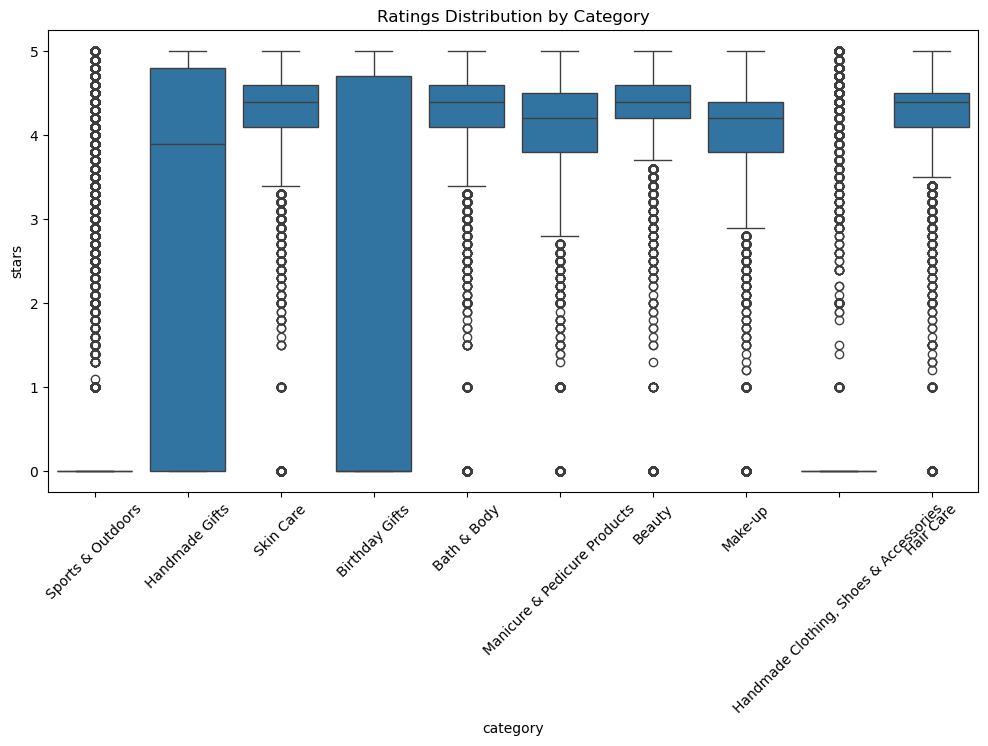

In [12]:
top10 = df_clean['category'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean[df_clean['category'].isin(top10)],
            x='category', y='stars')

plt.xticks(rotation=45)
plt.title("Ratings Distribution by Category")
plt.show()

In [13]:
corr = df_clean['price'].corr(df_clean['stars'])
print("Correlation:", corr)

Correlation: -0.0776729987818131


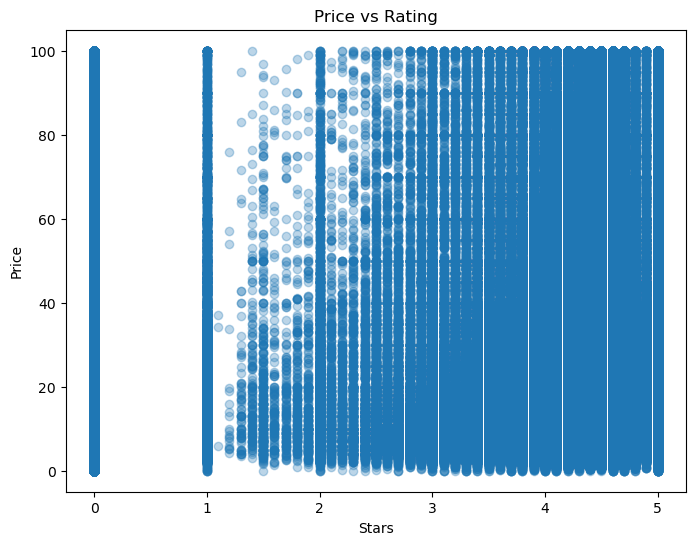

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(df_clean['stars'], df_clean['price'], alpha=0.3)

plt.xlabel("Stars")
plt.ylabel("Price")
plt.title("Price vs Rating")
plt.show()

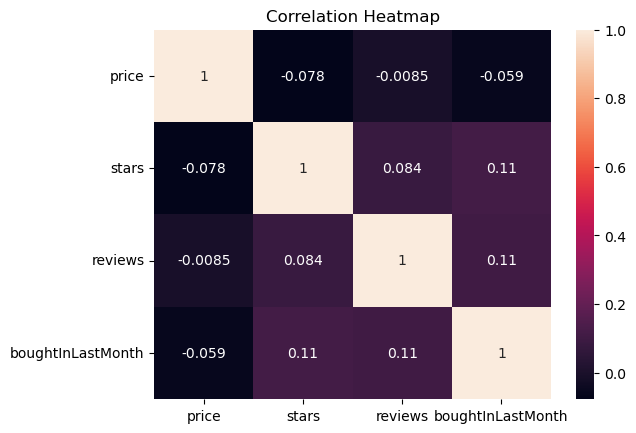

In [15]:
import seaborn as sns

corr_matrix = df_clean[['price', 'stars', 'reviews', 'boughtInLastMonth']].corr()

sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

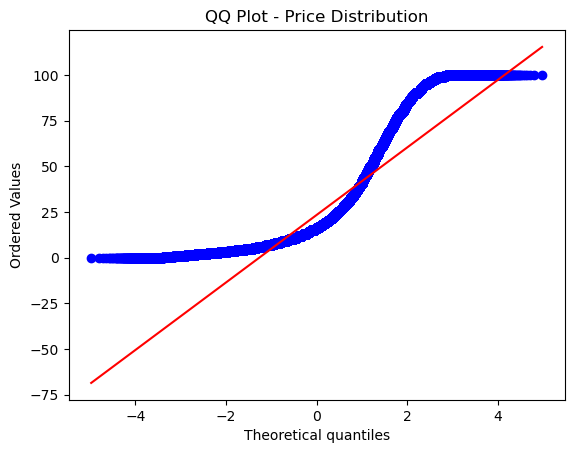

In [16]:
import scipy.stats as stats

stats.probplot(df_clean['price'], dist="norm", plot=plt)
plt.title("QQ Plot - Price Distribution")
plt.show()

"""
🔍 Conclusions & Observations

1. Best-Seller Trends:
The distribution of best-sellers varies across product categories, suggesting that
category plays a role in determining whether a product becomes a best-seller.
The Chi-square test indicates that this relationship is statistically significant,
while Cramér’s V suggests the strength of the association is relatively weak/moderate.

2. Price Distribution Across Categories:
Product prices differ substantially between categories. Some categories show higher
median and average prices, indicating premium segments, while others are more
price-sensitive. The presence of outliers required cleaning to ensure meaningful analysis.

3. Ratings Across Categories:
Customer ratings are relatively consistent across most categories, although some
categories show slightly higher median ratings. Overall, ratings tend to cluster
towards the higher end (around 4–5 stars), which is typical for e-commerce platforms.

4. Price vs Rating Relationship:
The correlation between price and rating is weak, indicating that more expensive
products do not necessarily receive better ratings. This suggests that perceived
value and product quality are not strictly tied to price.

5. General Insight:
Category is a stronger driver of product performance (best-seller status and pricing)
than price or ratings alone. Businesses should consider category-specific strategies
when optimizing pricing, positioning, and product development.
"""